In [ ]:

import requests
import pandas as pd
from datetime import datetime

API_KEY = "###########"

# API endpoint
BASE_URL = "https://api.openweathermap.org/data/2.5/weather"

# List of cities
cities = ["Lagos", "Abuja", "Port Harcourt"]

# Store weather data
weather_data = []

# Loop through each city
for city in cities:
    params = {
        "q": city,
        "appid": API_KEY,
        "units": "metric"
    }

    response = requests.get(BASE_URL, params=params)

    if response.status_code == 200:
        data = response.json()

        weather_data.append({
            "City Name": data["name"],
            "Temperature (°C)": data["main"]["temp"],
            "Humidity (%)": data["main"]["humidity"],
            "Weather Condition": data["weather"][0]["description"],
            "Wind Speed (m/s)": data["wind"]["speed"],
            "Date and Time": datetime.fromtimestamp(data["dt"])
        })

        # Display the raw JSON response
        print(f"\nRaw data for {city}:")
        print(data)

    else:
        print(f"Could not retrieve data for {city}")
        print(response.json())

# Convert to a DataFrame
weather_df = pd.DataFrame(weather_data)

print("\nWeather Summary")
print(weather_df)
weather_df.to_csv("weather_summary.csv", index=False)

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df =pd.read_csv("weather_summary.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City Name          3 non-null      object 
 1   Temperature (°C)   3 non-null      float64
 2   Humidity (%)       3 non-null      int64  
 3   Weather Condition  3 non-null      object 
 4   Wind Speed (m/s)   3 non-null      float64
 5   Date and Time      3 non-null      object 
dtypes: float64(2), int64(1), object(3)
memory usage: 276.0+ bytes


In [5]:
df = df.rename(columns={"Temperature (°C)": "Temperature_C", "Humidity (%)": "Humidity", 
                   "Weather Condition": "Weather_Condition", "Wind Speed (m/s)": "Wind_Speed_m_s", 
                   "Date and Time": "Date_Time", "City Name": "City_Name"})    

In [6]:
df

,City_Name,Temperature_C,Humidity,Weather_Condition,Wind_Speed_m_s,Date_Time
0,Lagos,24.56,89,overcast clouds,0.54,2026-07-18 14:40:42
1,Abuja,25.52,82,broken clouds,1.84,2026-07-18 14:47:09
2,Port Harcourt,27.16,72,overcast clouds,1.13,2026-07-18 14:46:21


In [7]:
df['Date_Time'] = pd.to_datetime(df['Date_Time'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   City_Name          3 non-null      object        
 1   Temperature_C      3 non-null      float64       
 2   Humidity           3 non-null      int64         
 3   Weather_Condition  3 non-null      object        
 4   Wind_Speed_m_s     3 non-null      float64       
 5   Date_Time          3 non-null      datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 276.0+ bytes


In [12]:
df= df.sort_values(by='City_Name')

In [13]:
df.to_csv("weather_summary_cleaned.csv", index=False)

In [21]:
df.describe()

,Temperature_C,Humidity,Wind_Speed_m_s,Date_Time
count,3.000000,3.000000,3.000000,3
mean,25.746667,81.000000,1.170000,2026-07-18 14:44:44
min,24.560000,72.000000,0.540000,2026-07-18 14:40:42
25%,25.040000,77.000000,0.835000,2026-07-18 14:43:31.500000
50%,25.520000,82.000000,1.130000,2026-07-18 14:46:21
75%,26.340000,85.500000,1.485000,2026-07-18 14:46:45
max,27.160000,89.000000,1.840000,2026-07-18 14:47:09
std,1.314737,8.544004,0.650922,NaN


In [20]:
## Average temperature
print(df["Temperature_C"].mean())

25.746666666666666


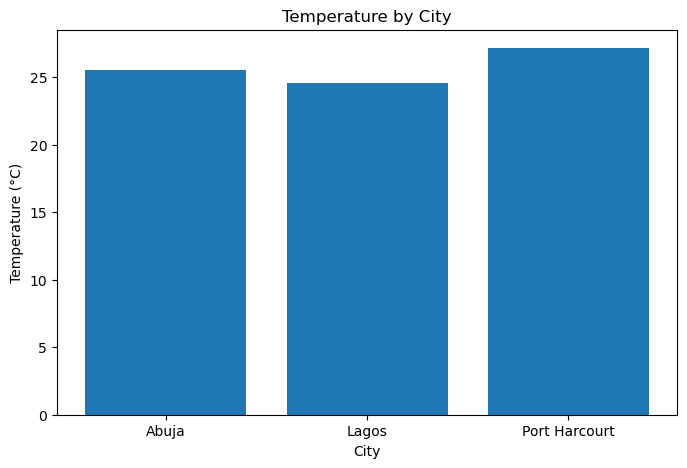

In [19]:


plt.figure(figsize=(8,5))
plt.bar(df["City_Name"], df["Temperature_C"])
plt.title("Temperature by City")
plt.xlabel("City")
plt.ylabel("Temperature (°C)")
plt.show()

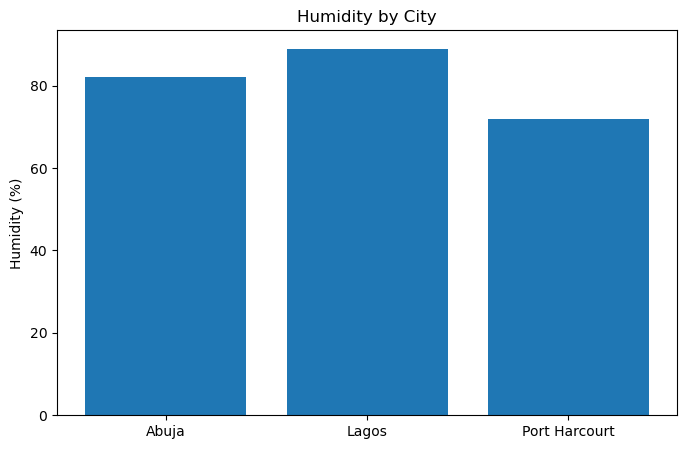

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(df["City_Name"], df["Humidity"])
plt.title("Humidity by City")
plt.ylabel("Humidity (%)")
plt.show()

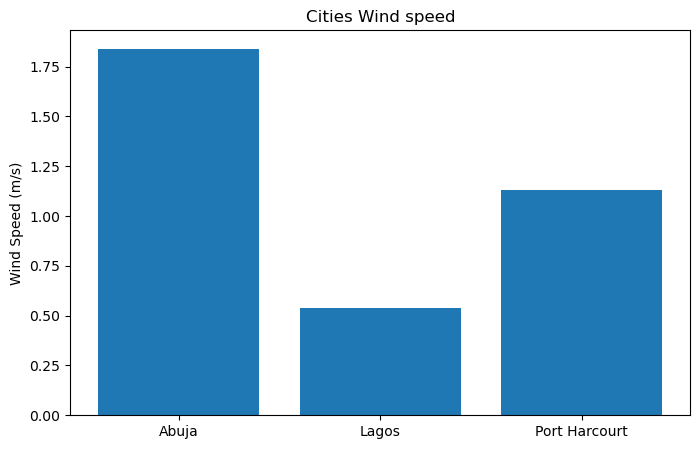

In [23]:
plt.figure(figsize=(8,5))
plt.bar(df["City_Name"], df["Wind_Speed_m_s"])
plt.title("Cities Wind speed")
plt.ylabel("Wind Speed (m/s)")
plt.show()

## Short Summary of Findings

The analysis of the weather data collected from **3** cities revealed noticeable differences in weather conditions across locations.

* **Temperature Comparison:** **Port Harcourt** recorded the highest temperature at **27.16°C**, while **Lagos** had the lowest temperature at **24.56°C**, indicating varying weather patterns across the selected cities.

* **Humidity Analysis:** The highest humidity level was observed in **Lagos** with **89%**, suggesting more moisture in the atmosphere compared to the other cities. The lowest humidity was recorded in **Port Harcourt** at **72%**.

* **Weather Conditions:** The weather conditions varied across the cities, with **overcast clouds** being the most common condition. 

* **Wind Speed:** **Abuja** experienced the highest wind speed of **1.84 m/s**, while **Lagos** recorded the lowest at **0.54 m/s**.

